# AQB-FAS Results Dashboard

Notebook này đọc kết quả đã train trong `outputs/` và hiển thị bảng, biểu đồ, confusion matrix để so sánh **Baseline MobileNetV3** với **AQB-FAS z64 b8**.

Chạy các cell từ trên xuống dưới. Nếu vừa train xong, hãy chạy `python scripts/make_artifacts.py` trước hoặc dùng cell bên dưới để regenerate artifacts.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists() and (ROOT.parent / 'outputs').exists():
    ROOT = ROOT.parent

OUTPUTS = ROOT / 'outputs'
RUNS = OUTPUTS / 'runs'
FIGURES = OUTPUTS / 'figures'
TABLES = OUTPUTS / 'tables'
RESULTS = OUTPUTS / 'results'

print('ROOT =', ROOT)

ROOT = d:\Paper2026\Paper-2026


## 1. Regenerate artifacts nếu cần

Cell này an toàn: nó chỉ đọc checkpoint/metrics hiện có và tạo lại bảng + hình trong `outputs/`.

In [2]:
# Chạy cell này nếu bạn muốn cập nhật lại bảng và hình từ outputs/runs.
# Nếu artifacts đã mới rồi thì có thể bỏ qua.
# subprocess.run([sys.executable, str(ROOT / 'scripts' / 'make_artifacts.py')], cwd=ROOT, check=True)

## 2. Bảng kết quả chính

Bảng này ưu tiên **test metrics**, vì test mới là số nên dùng trong paper. Validation được giữ lại để xem gap giữa val và test.

In [3]:
summary_path = RESULTS / 'summary.csv'
table_path = TABLES / 'main_results.csv'

summary = pd.read_csv(summary_path)
main_table = pd.read_csv(table_path)

display(Markdown(f'**summary.csv:** `{summary_path}`'))
display(summary)

display(Markdown(f'**main_results.csv:** `{table_path}`'))
display(main_table)

**summary.csv:** `d:\Paper2026\Paper-2026\outputs\results\summary.csv`

,run_name,method,model,dz,bits,bitrate_bits,best_epoch,train_loss,val_acc,val_precision,...,test_precision,test_recall,test_f1,test_auc,test_apcer,test_bpcer,test_acer,test_threshold,checkpoint,history
0,baseline_mbv3,Baseline MobileNetV3,baseline_mbv3,NaN,NaN,NaN,5,0.001653,0.999076,0.999241,...,0.998886,0.778356,0.874939,0.994470,0.221644,0.002058,0.111851,0.999000,D:\Paper2026\Paper-2026\outputs\runs\baseline_...,D:\Paper2026\Paper-2026\outputs\runs\baseline_...
1,aqb_z16_b8,"AQB-FAS z=16, b=8",aqb_fas,16.0,8.0,128.0,1,0.046804,0.998892,0.999605,...,0.999467,0.794315,0.885160,0.996124,0.205685,0.001004,0.103344,0.394152,D:\Paper2026\Paper-2026\outputs\runs\aqb_z16_b...,D:\Paper2026\Paper-2026\outputs\runs\aqb_z16_b...
2,aqb_z32_b8,"AQB-FAS z=32, b=8",aqb_fas,32.0,8.0,256.0,8,0.008198,0.999282,0.999696,...,0.999596,0.786314,0.880220,0.995950,0.213686,0.000753,0.107219,0.016121,D:\Paper2026\Paper-2026\outputs\runs\aqb_z32_b...,D:\Paper2026\Paper-2026\outputs\runs\aqb_z32_b...
3,aqb_z64_b4,"AQB-FAS z=64, b=4",aqb_fas,64.0,4.0,256.0,1,0.042929,0.999076,0.999514,...,0.999379,0.749783,0.856773,0.996398,0.250217,0.001104,0.125661,0.308465,D:\Paper2026\Paper-2026\outputs\runs\aqb_z64_b...,D:\Paper2026\Paper-2026\outputs\runs\aqb_z64_b...
4,aqb_z64_b8,"AQB-FAS z=64, b=8",aqb_fas,64.0,8.0,512.0,6,0.014050,0.999425,0.999787,...,0.999853,0.718628,0.836229,0.995190,0.281372,0.000251,0.140812,0.817545,D:\Paper2026\Paper-2026\outputs\runs\aqb_z64_b...,D:\Paper2026\Paper-2026\outputs\runs\aqb_z64_b...
5,aqb_z128_b8,"AQB-FAS z=128, b=8",aqb_fas,128.0,8.0,1024.0,4,0.015896,0.998502,0.999362,...,0.998944,0.680572,0.809583,0.984789,0.319428,0.001707,0.160567,0.777222,D:\Paper2026\Paper-2026\outputs\runs\aqb_z128_...,D:\Paper2026\Paper-2026\outputs\runs\aqb_z128_...


**main_results.csv:** `d:\Paper2026\Paper-2026\outputs\tables\main_results.csv`

,Method,Latent bits,Best epoch,Test ACC (%),Test Precision (%),Test Recall (%),Test F1 (%),Test AUC (%),Test APCER (%),Test BPCER (%),Test ACER (%),Val ACER (%)
0,Baseline MobileNetV3,Full image,5,84.349,99.889,77.836,87.494,99.447,22.164,0.206,11.185,0.110
1,"AQB-FAS z=16, b=8",128.0,1,85.502,99.947,79.431,88.516,99.612,20.569,0.100,10.334,0.103
2,"AQB-FAS z=32, b=8",256.0,8,84.947,99.960,78.631,88.022,99.595,21.369,0.075,10.722,0.070
3,"AQB-FAS z=64, b=4",256.0,1,82.367,99.938,74.978,85.677,99.640,25.022,0.110,12.566,0.095
4,"AQB-FAS z=64, b=8",512.0,6,80.201,99.985,71.863,83.623,99.519,28.137,0.025,14.081,0.054
5,"AQB-FAS z=128, b=8",1024.0,4,77.481,99.894,68.057,80.958,98.479,31.943,0.171,16.057,0.145


## 3. So sánh baseline vs AQB-FAS trên test set

- **ACER thấp hơn là tốt hơn**.
- **AUC/ACC cao hơn là tốt hơn**.
- Nếu AUC cao nhưng ACER cao, thường có vấn đề threshold/calibration giữa val và test.

,method,test_acc,test_precision,test_recall,test_f1,test_auc,test_apcer,test_bpcer,test_acer,val_acer
0,Baseline MobileNetV3,84.349,99.889,77.836,87.494,99.447,22.164,0.206,11.185,0.110
1,"AQB-FAS z=16, b=8",85.502,99.947,79.431,88.516,99.612,20.569,0.100,10.334,0.103
2,"AQB-FAS z=32, b=8",84.947,99.960,78.631,88.022,99.595,21.369,0.075,10.722,0.070
3,"AQB-FAS z=64, b=4",82.367,99.938,74.978,85.677,99.640,25.022,0.110,12.566,0.095
4,"AQB-FAS z=64, b=8",80.201,99.985,71.863,83.623,99.519,28.137,0.025,14.081,0.054
5,"AQB-FAS z=128, b=8",77.481,99.894,68.057,80.958,98.479,31.943,0.171,16.057,0.145


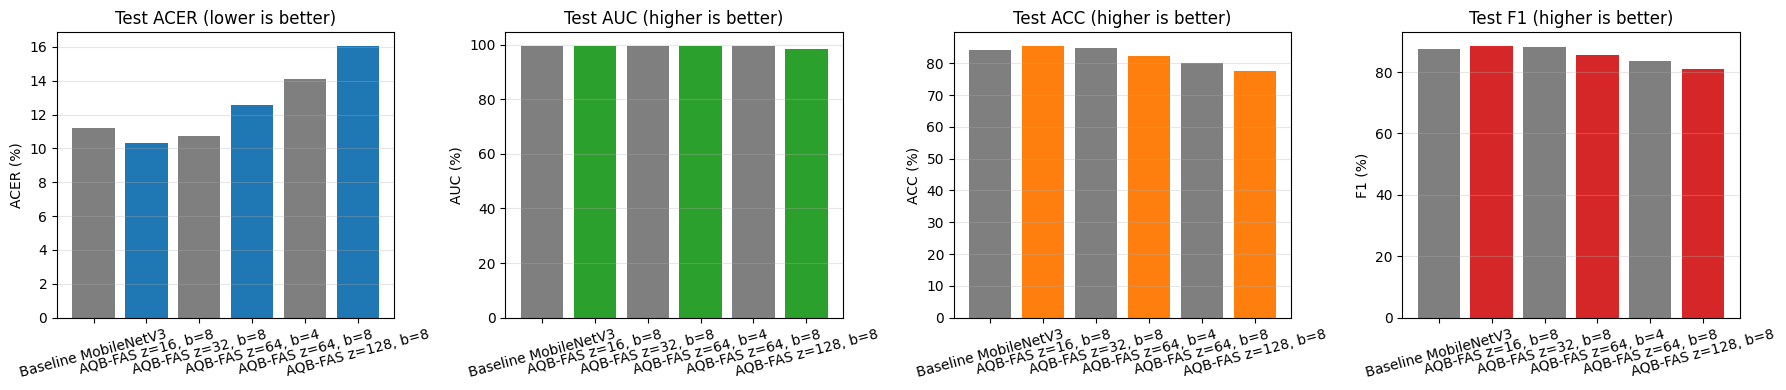

In [4]:
metric_cols = [
    'test_acc', 'test_precision', 'test_recall', 'test_f1',
    'test_auc', 'test_apcer', 'test_bpcer', 'test_acer', 'val_acer'
]
available_cols = ['method'] + [col for col in metric_cols if col in summary.columns]
compare = summary[available_cols].copy()
for col in [col for col in available_cols if col != 'method']:
    compare[col] = compare[col] * 100
display(compare.style.format({c: '{:.3f}' for c in compare.columns if c != 'method'}))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
x = compare['method']

axes[0].bar(x, compare['test_acer'], color=['tab:gray', 'tab:blue'][:len(compare)])
axes[0].set_title('Test ACER (lower is better)')
axes[0].set_ylabel('ACER (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(x, compare['test_auc'], color=['tab:gray', 'tab:green'][:len(compare)])
axes[1].set_title('Test AUC (higher is better)')
axes[1].set_ylabel('AUC (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(x, compare['test_acc'], color=['tab:gray', 'tab:orange'][:len(compare)])
axes[2].set_title('Test ACC (higher is better)')
axes[2].set_ylabel('ACC (%)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(True, axis='y', alpha=0.3)

if 'test_f1' in compare.columns:
    axes[3].bar(x, compare['test_f1'], color=['tab:gray', 'tab:red'][:len(compare)])
    axes[3].set_title('Test F1 (higher is better)')
    axes[3].set_ylabel('F1 (%)')
    axes[3].tick_params(axis='x', rotation=15)
    axes[3].grid(True, axis='y', alpha=0.3)
else:
    axes[3].axis('off')

plt.tight_layout()
plt.show()

## 4. Validation vs test gap

Dùng plot này để chứng minh rằng validation đang lạc quan hơn test. Đây là phần rất hữu ích khi viết Discussion hoặc Limitations.

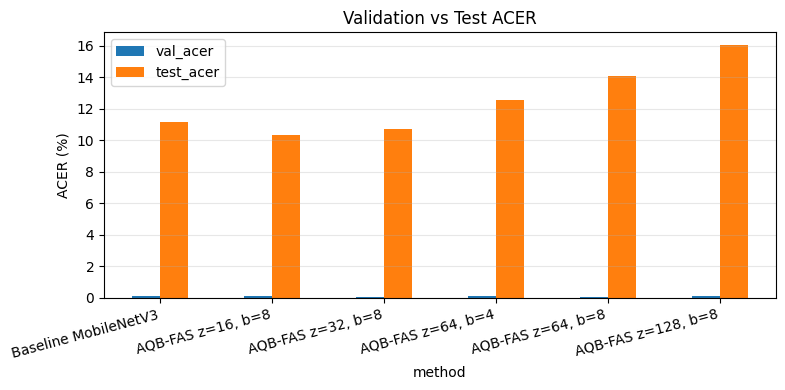

,method,val_acer,test_acer
0,Baseline MobileNetV3,0.109617,11.185081
1,"AQB-FAS z=16, b=8",0.103441,10.334444
2,"AQB-FAS z=32, b=8",0.069647,10.721921
3,"AQB-FAS z=64, b=4",0.094741,12.566060
4,"AQB-FAS z=64, b=8",0.054064,14.081166
5,"AQB-FAS z=128, b=8",0.145499,16.056713


In [5]:
gap = summary[['method', 'val_acer', 'test_acer']].copy()
gap['val_acer'] *= 100
gap['test_acer'] *= 100

ax = gap.set_index('method')[['val_acer', 'test_acer']].plot(kind='bar', figsize=(8, 4))
ax.set_title('Validation vs Test ACER')
ax.set_ylabel('ACER (%)')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

display(gap)

## 5. Confusion matrix trên test set

Hàng là nhãn thật, cột là dự đoán. Với PAD/FAS:

- `FN`: spoof bị nhầm thành live, làm APCER tăng.
- `FP`: live bị nhầm thành spoof, làm BPCER tăng.

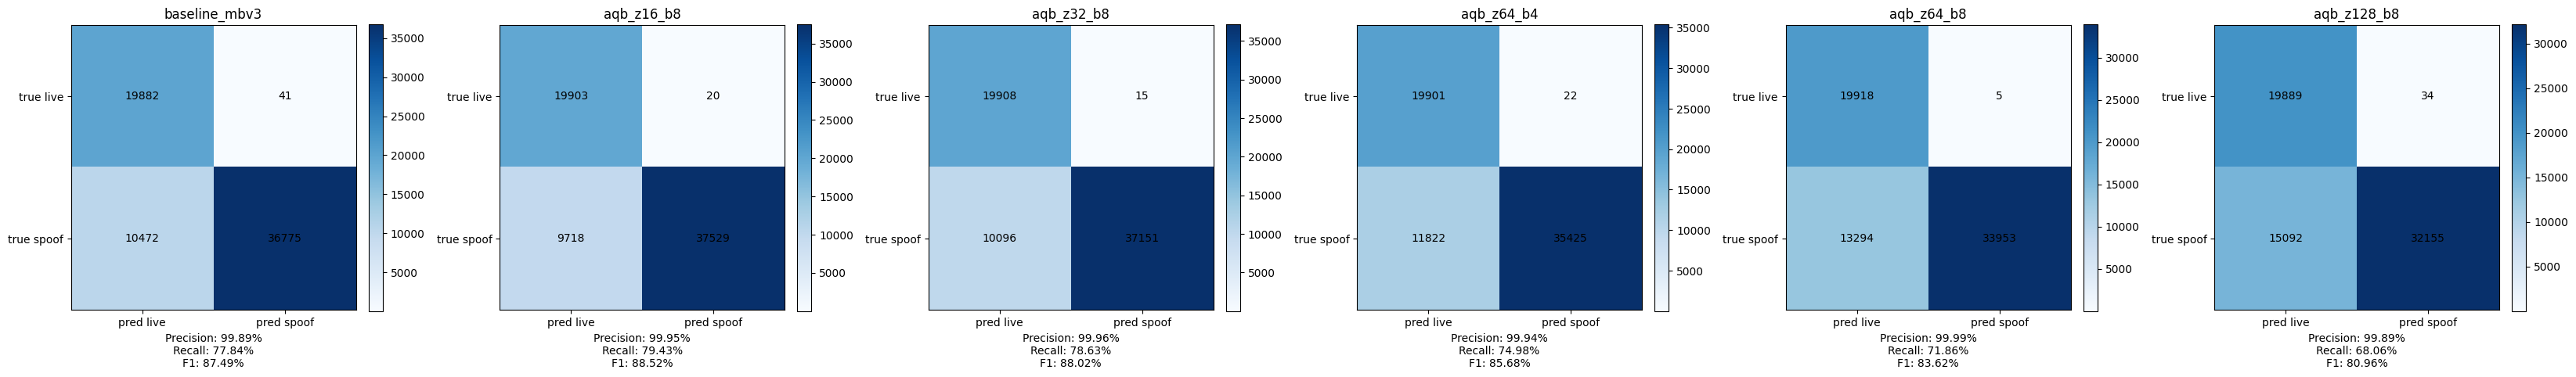

,run_name,precision,recall,f1,tp,fp,fn,tn
0,baseline_mbv3,0.9989,0.7784,0.8749,36775,41,10472,19882
1,aqb_z16_b8,0.9995,0.7943,0.8852,37529,20,9718,19903
2,aqb_z32_b8,0.9996,0.7863,0.8802,37151,15,10096,19908
3,aqb_z64_b4,0.9994,0.7498,0.8568,35425,22,11822,19901
4,aqb_z64_b8,0.9999,0.7186,0.8362,33953,5,13294,19918
5,aqb_z128_b8,0.9989,0.6806,0.8096,32155,34,15092,19889


In [6]:
def load_test_metrics(run_name):
    path = RUNS / run_name / 'test_metrics.json'
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def prf_from_counts(m):
    tp, fp, fn = m['tp'], m['fp'], m['fn']
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return precision, recall, f1

run_names = summary['run_name'].tolist()
fig, axes = plt.subplots(1, len(run_names), figsize=(5.5 * len(run_names), 4.8))
if len(run_names) == 1:
    axes = [axes]

prf_rows = []
for ax, run_name in zip(axes, run_names):
    m = load_test_metrics(run_name)
    precision, recall, f1 = prf_from_counts(m)
    prf_rows.append({
        'run_name': run_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': m['tp'],
        'fp': m['fp'],
        'fn': m['fn'],
        'tn': m['tn'],
    })
    cm = [[m['tn'], m['fp']], [m['fn'], m['tp']]]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(run_name)
    ax.set_xticks([0, 1], ['pred live', 'pred spoof'])
    ax.set_yticks([0, 1], ['true live', 'true spoof'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i][j], ha='center', va='center', color='black')
    ax.set_xlabel(
        f"Precision: {precision * 100:.2f}%\n"
        f"Recall: {recall * 100:.2f}%\n"
        f"F1: {f1 * 100:.2f}%"
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

prf_table = pd.DataFrame(prf_rows)
display(prf_table.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1': '{:.4f}',
}))

## 6. Training curves đã xuất ra file PNG

Các hình này được tạo bởi `scripts/plot_training_curves.py`.

### baseline_mbv3

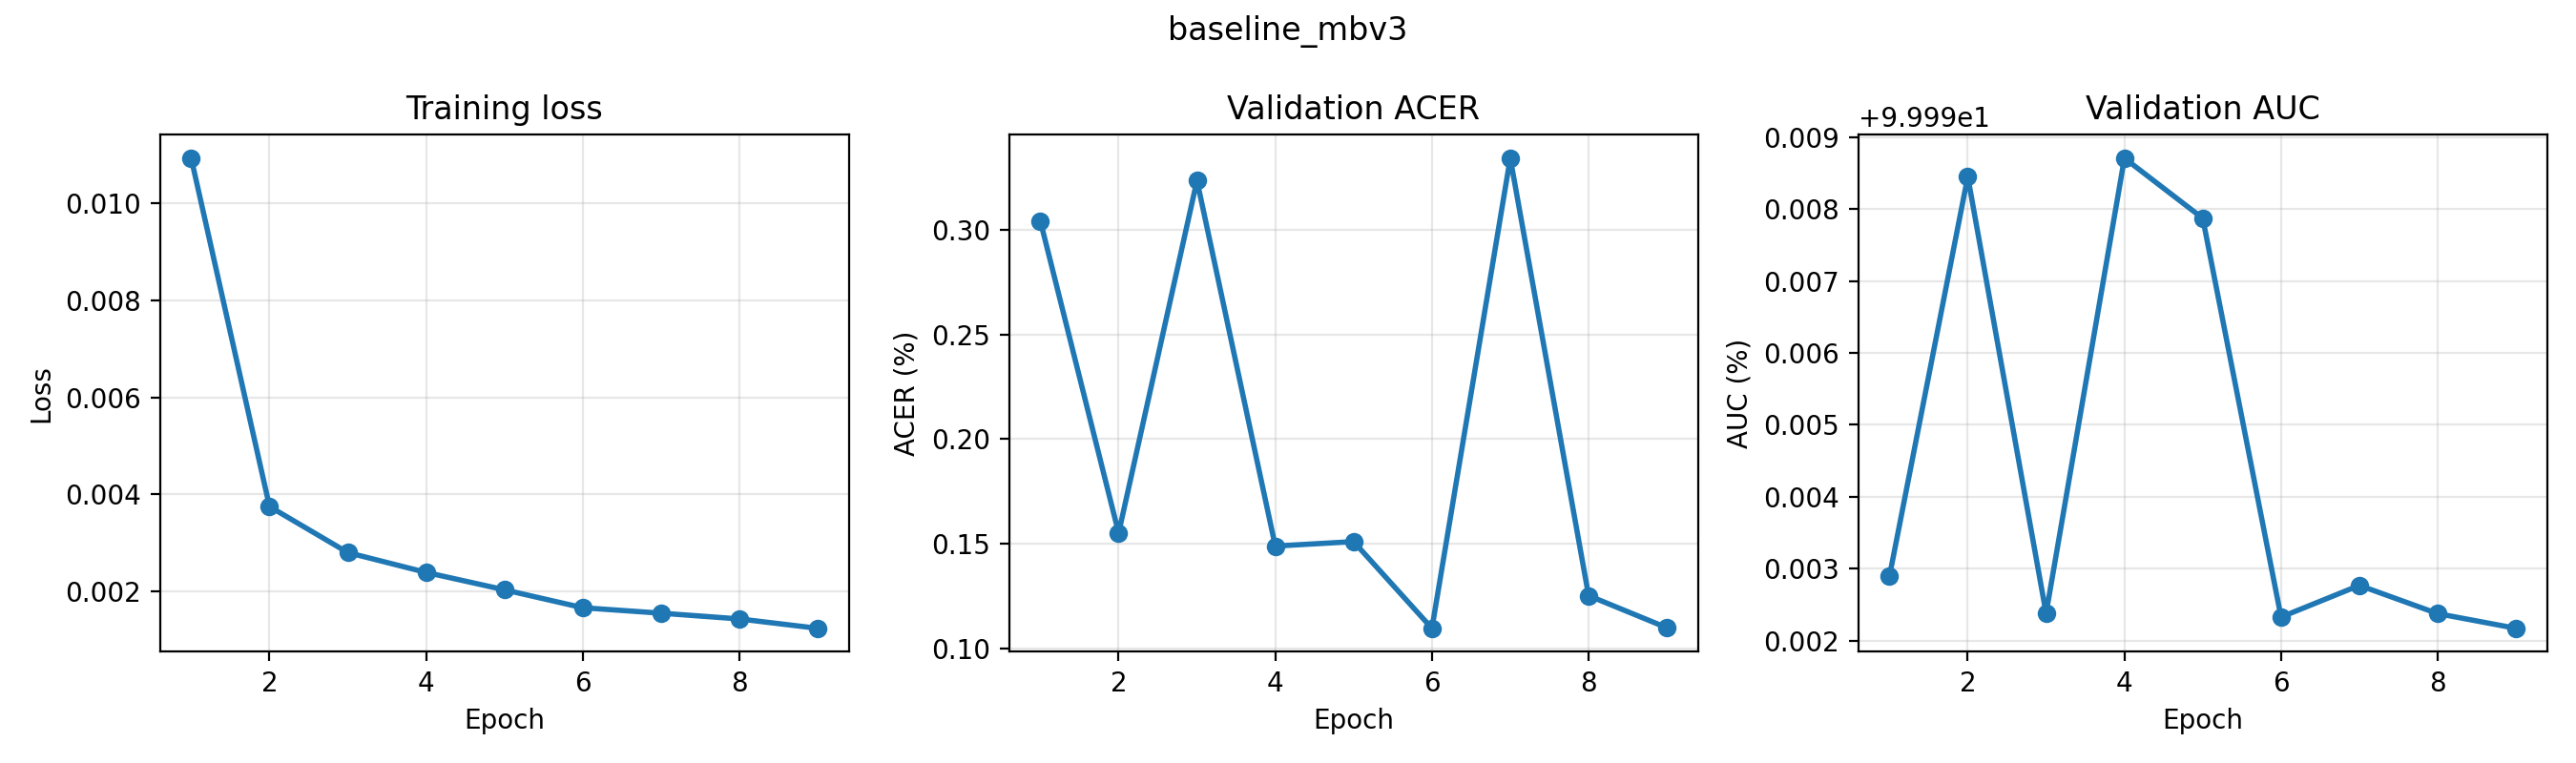

### aqb_z16_b8

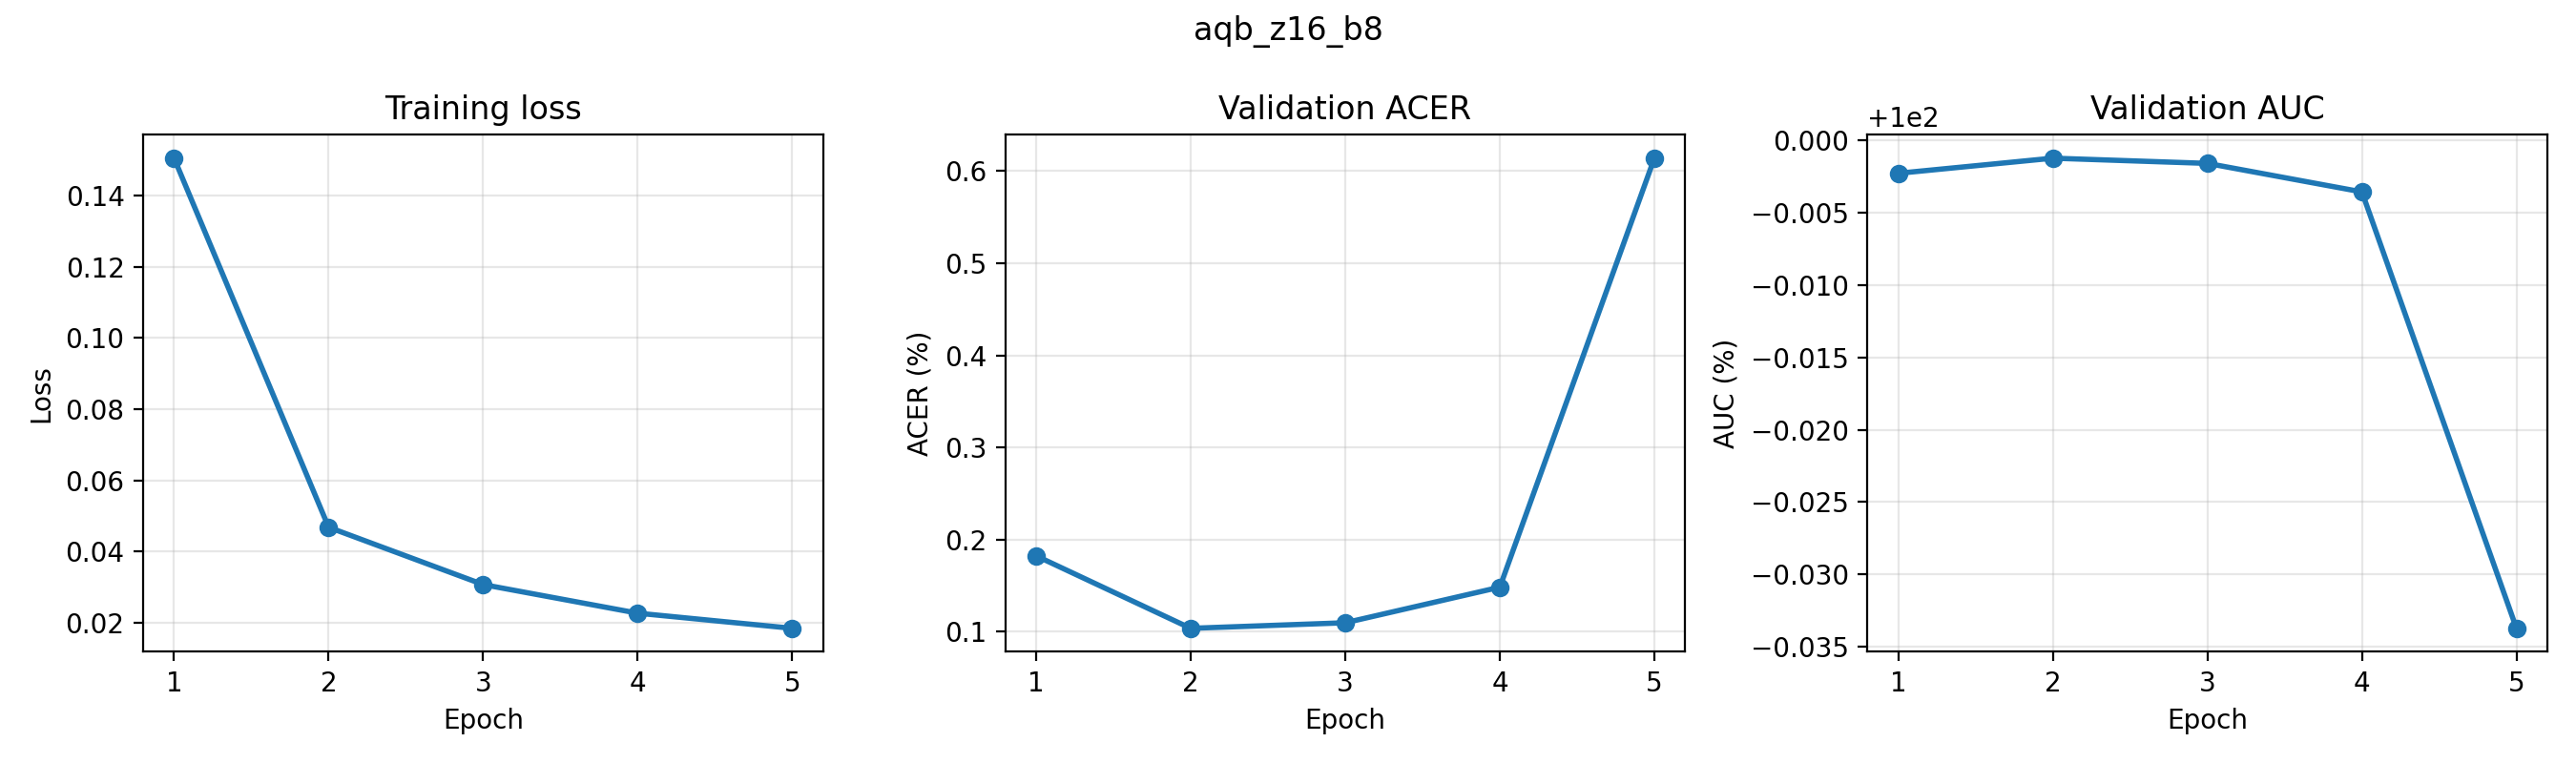

### aqb_z32_b8

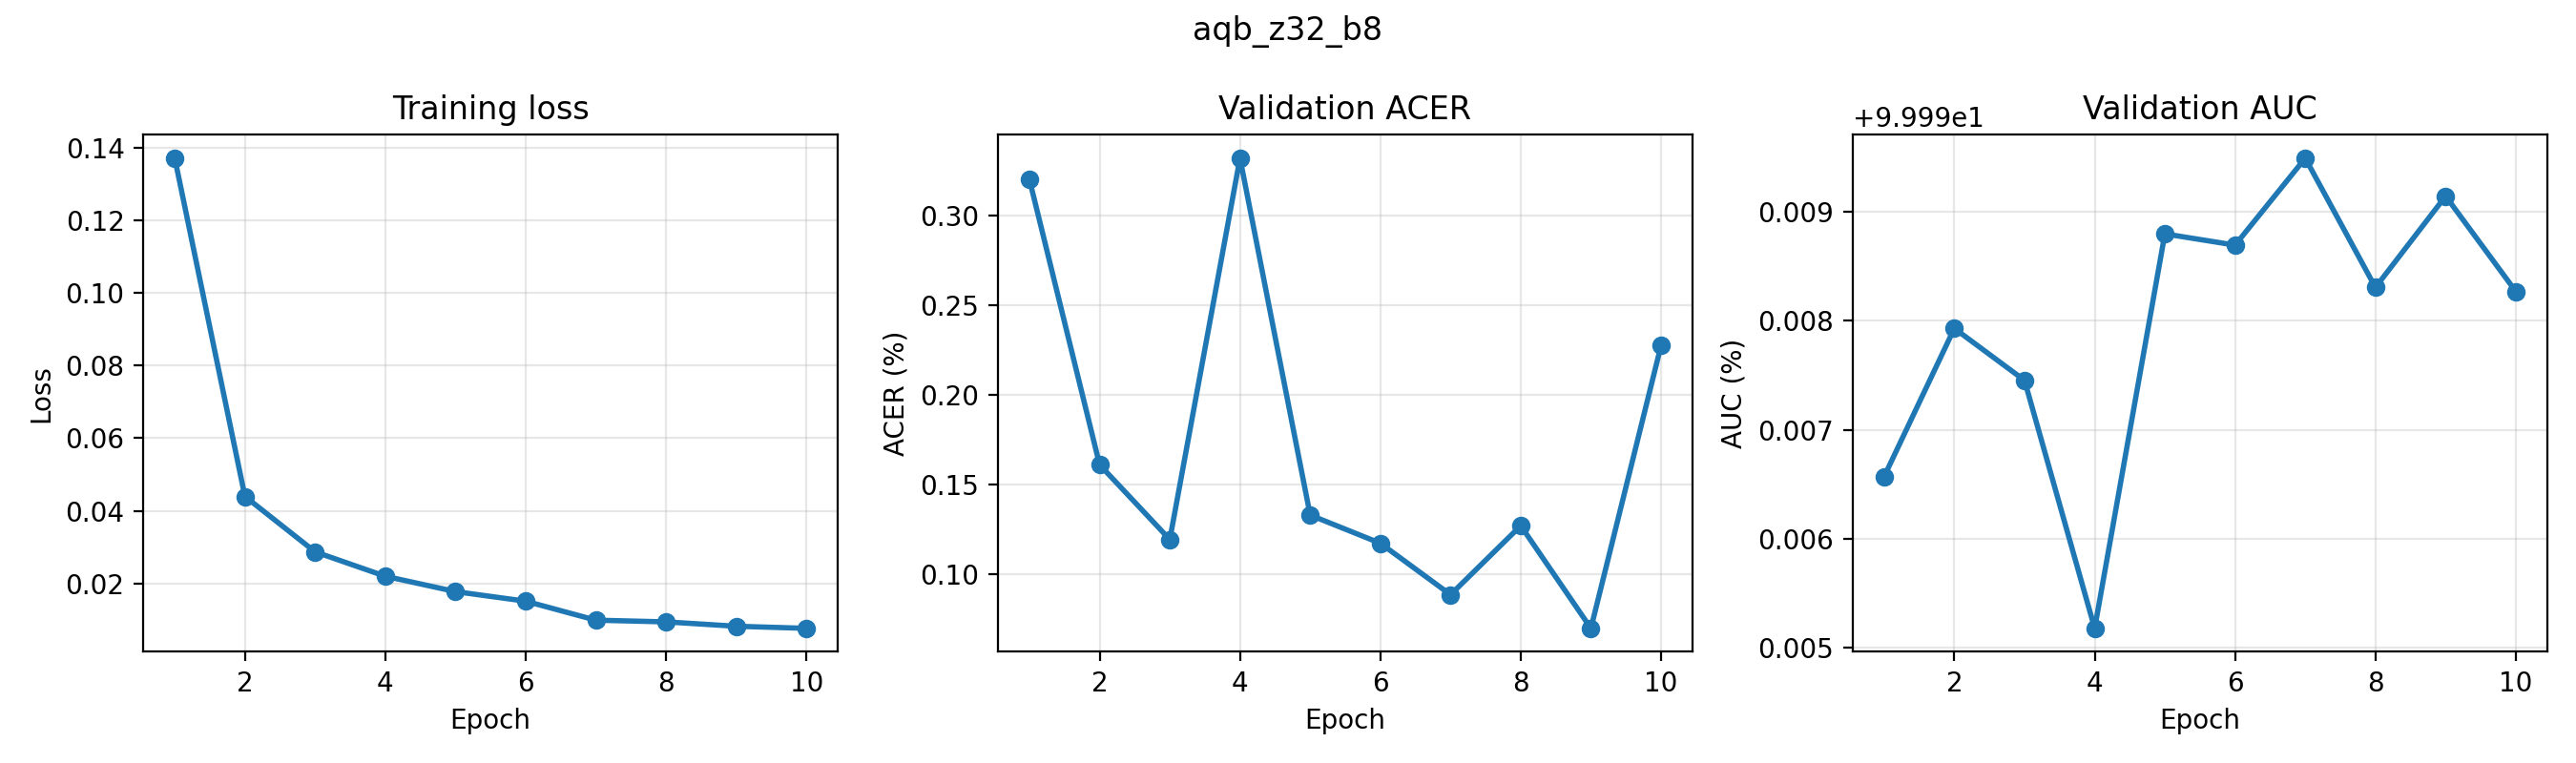

### aqb_z64_b4

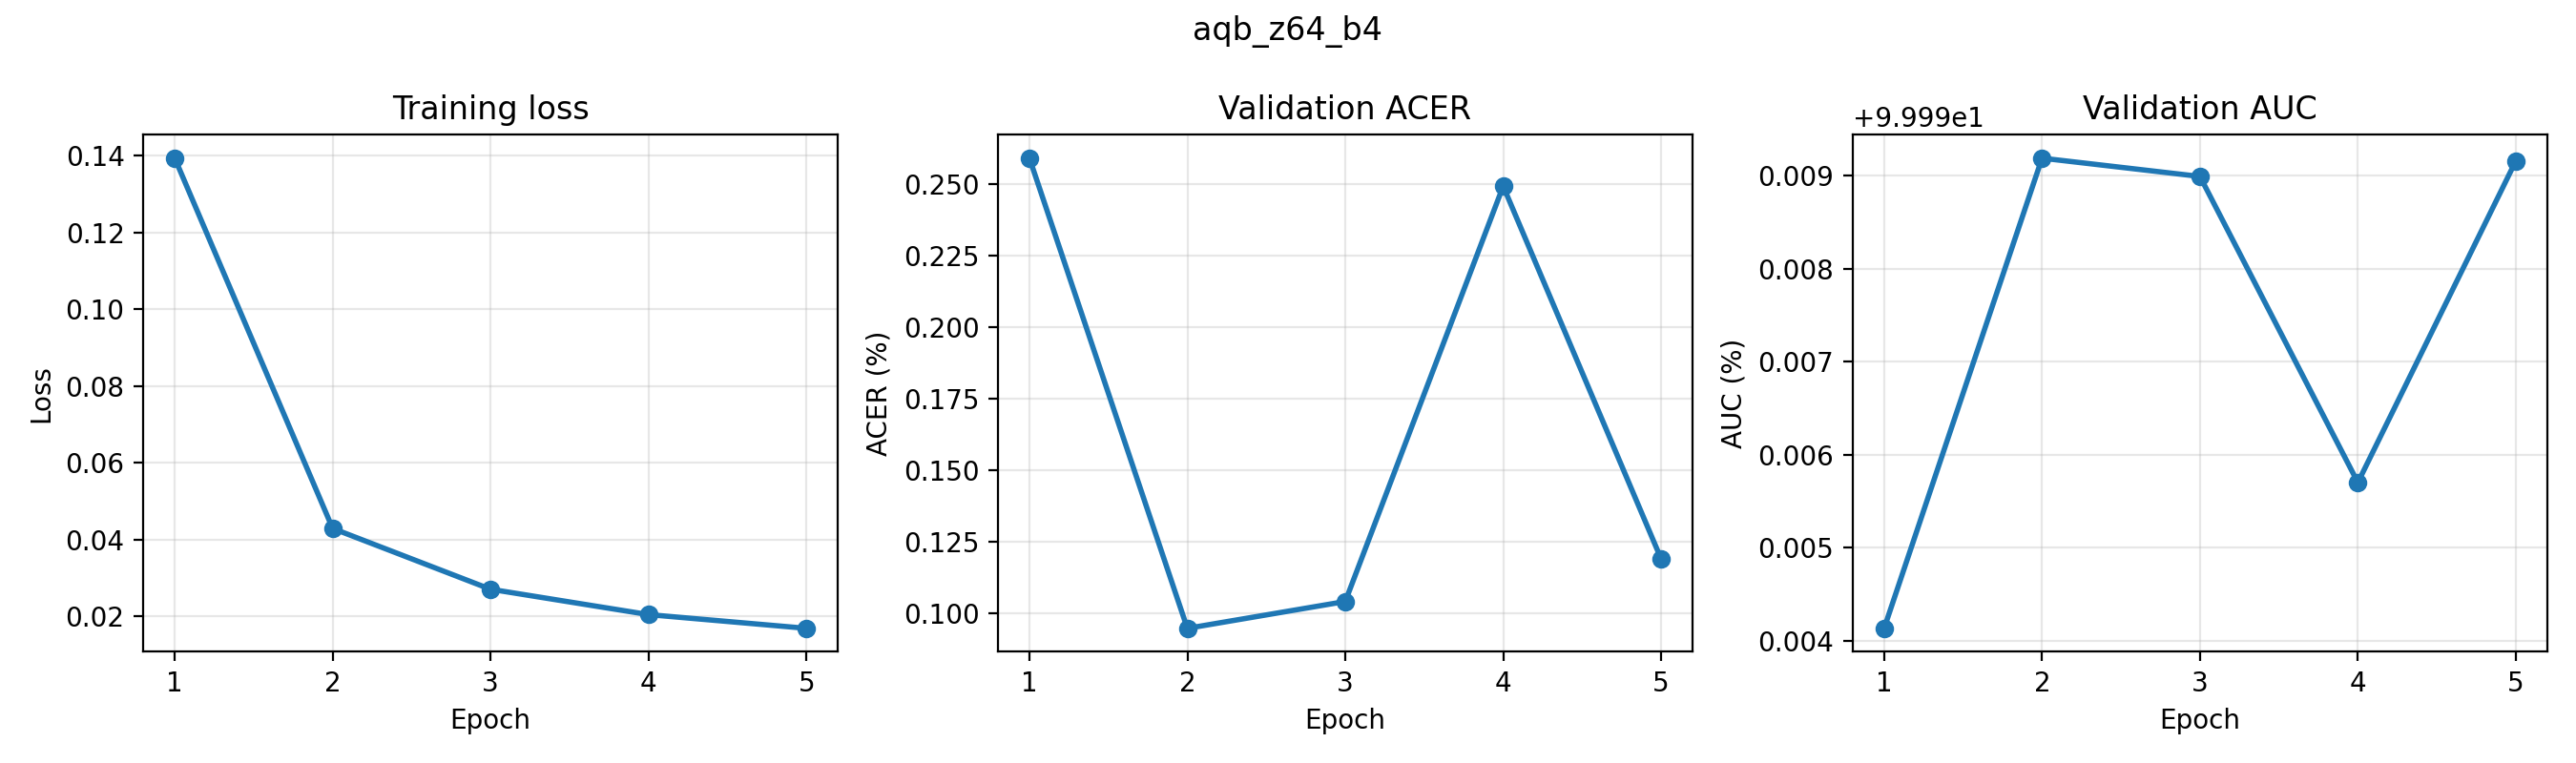

### aqb_z64_b8

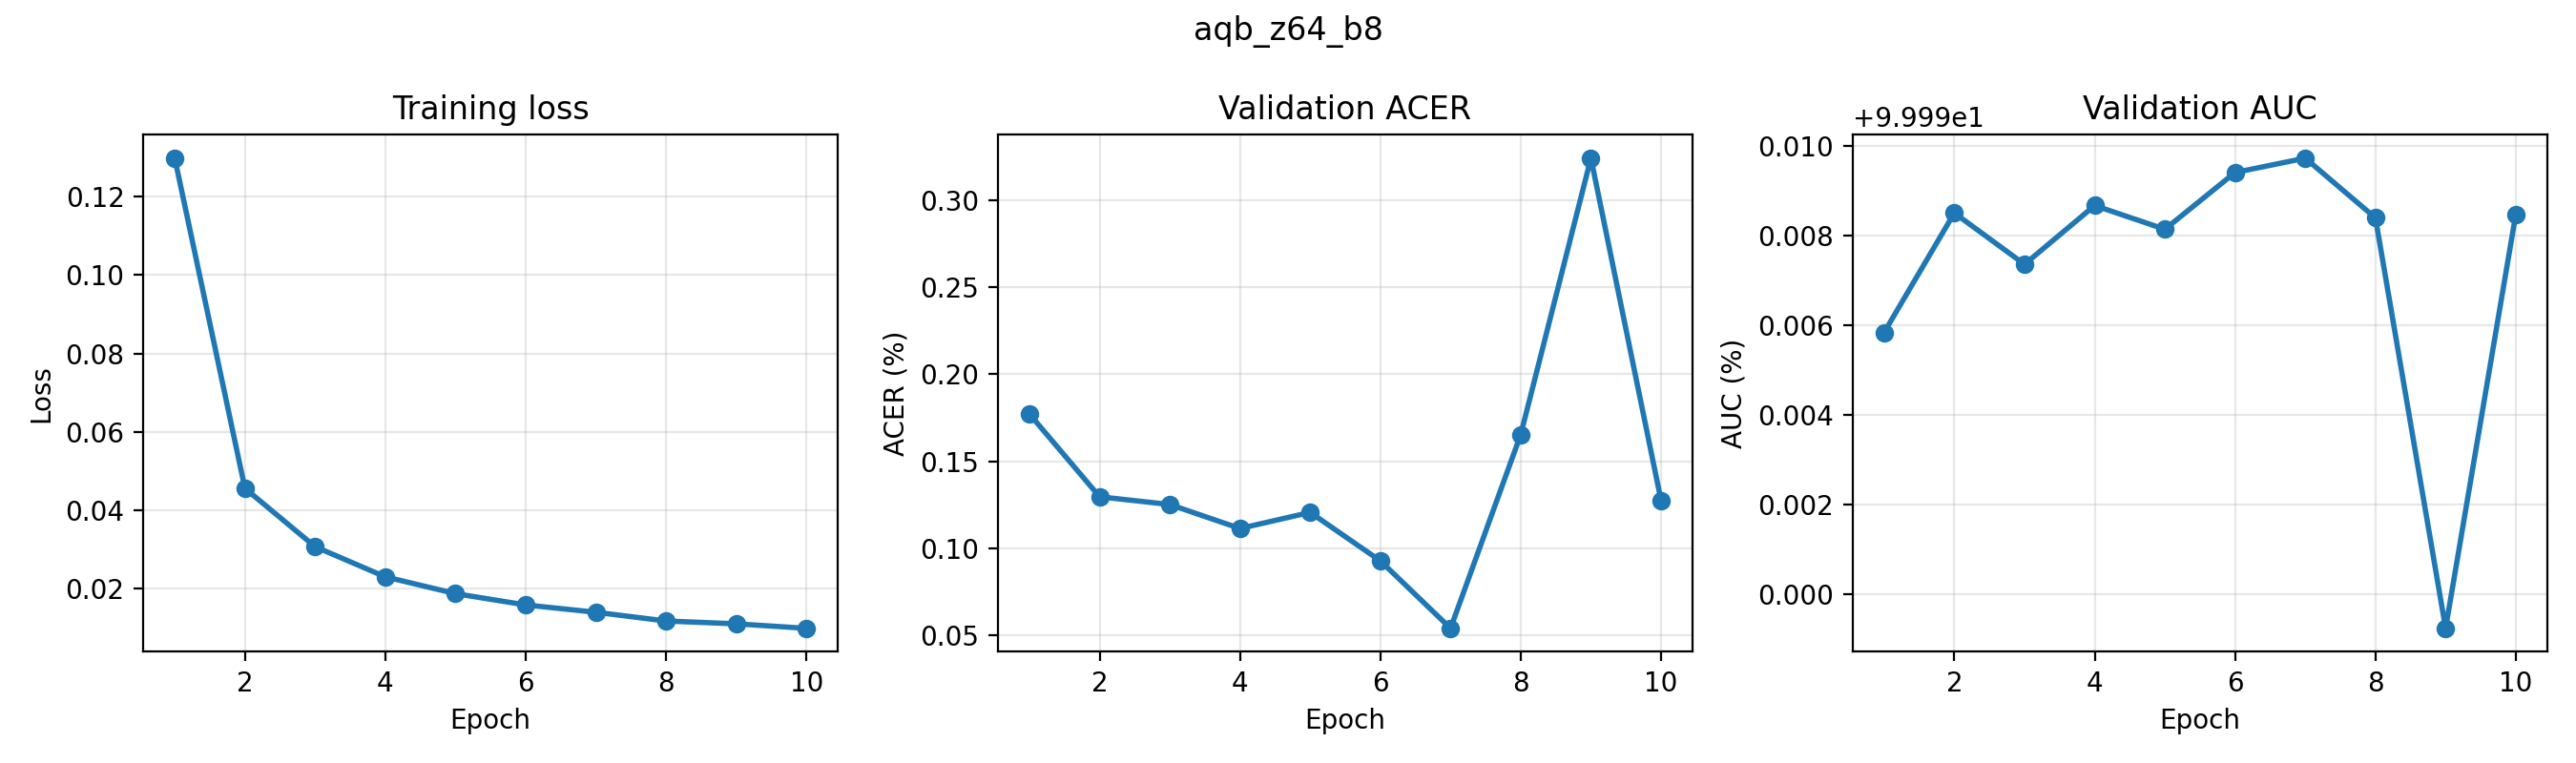

### aqb_z128_b8

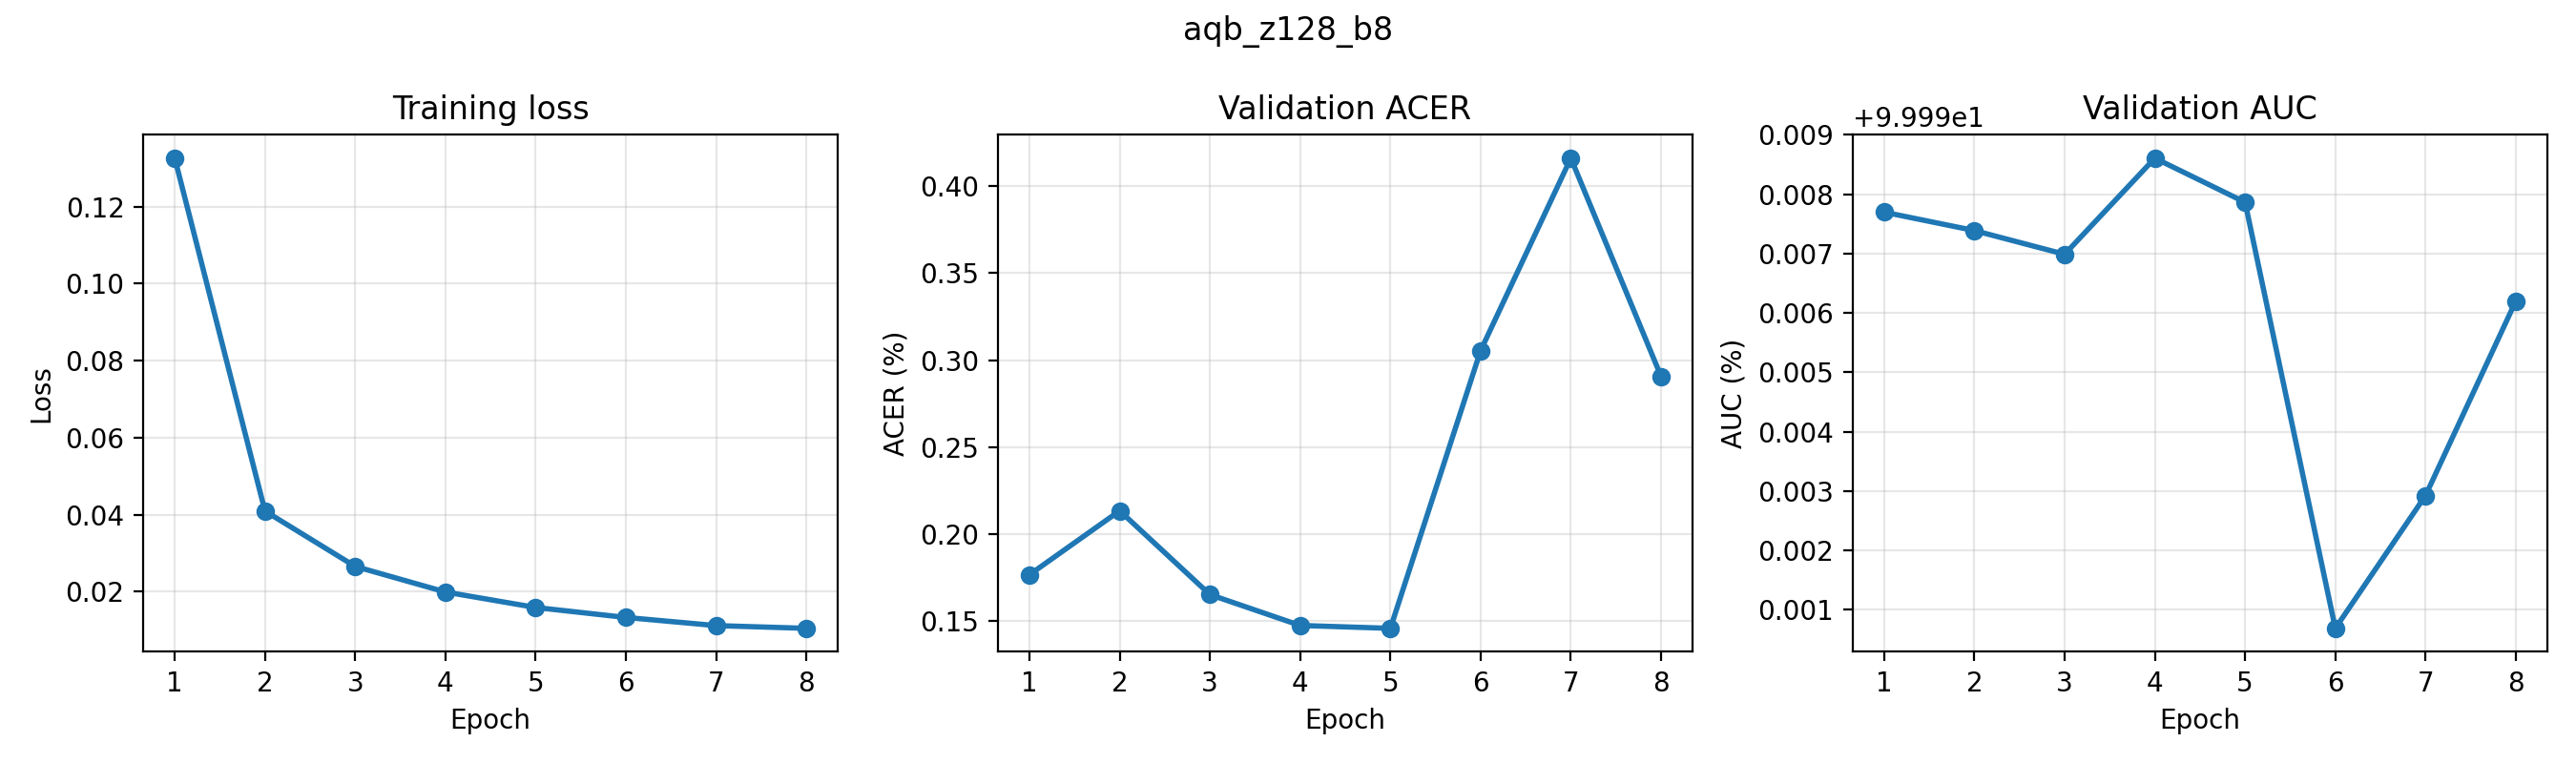

In [7]:
for run_name in summary['run_name']:
    image_path = FIGURES / f'training_curves_{run_name}.png'
    if image_path.exists():
        display(Markdown(f'### {run_name}'))
        display(Image(filename=str(image_path)))
    else:
        print('Missing', image_path)

## 7. Utility vs bitrate

Hình này sẽ hữu ích hơn sau khi chạy thêm các config bitrate khác như `aqb_z16_b8`, `aqb_z32_b8`, `aqb_z64_b4`, `aqb_z128_b8`.

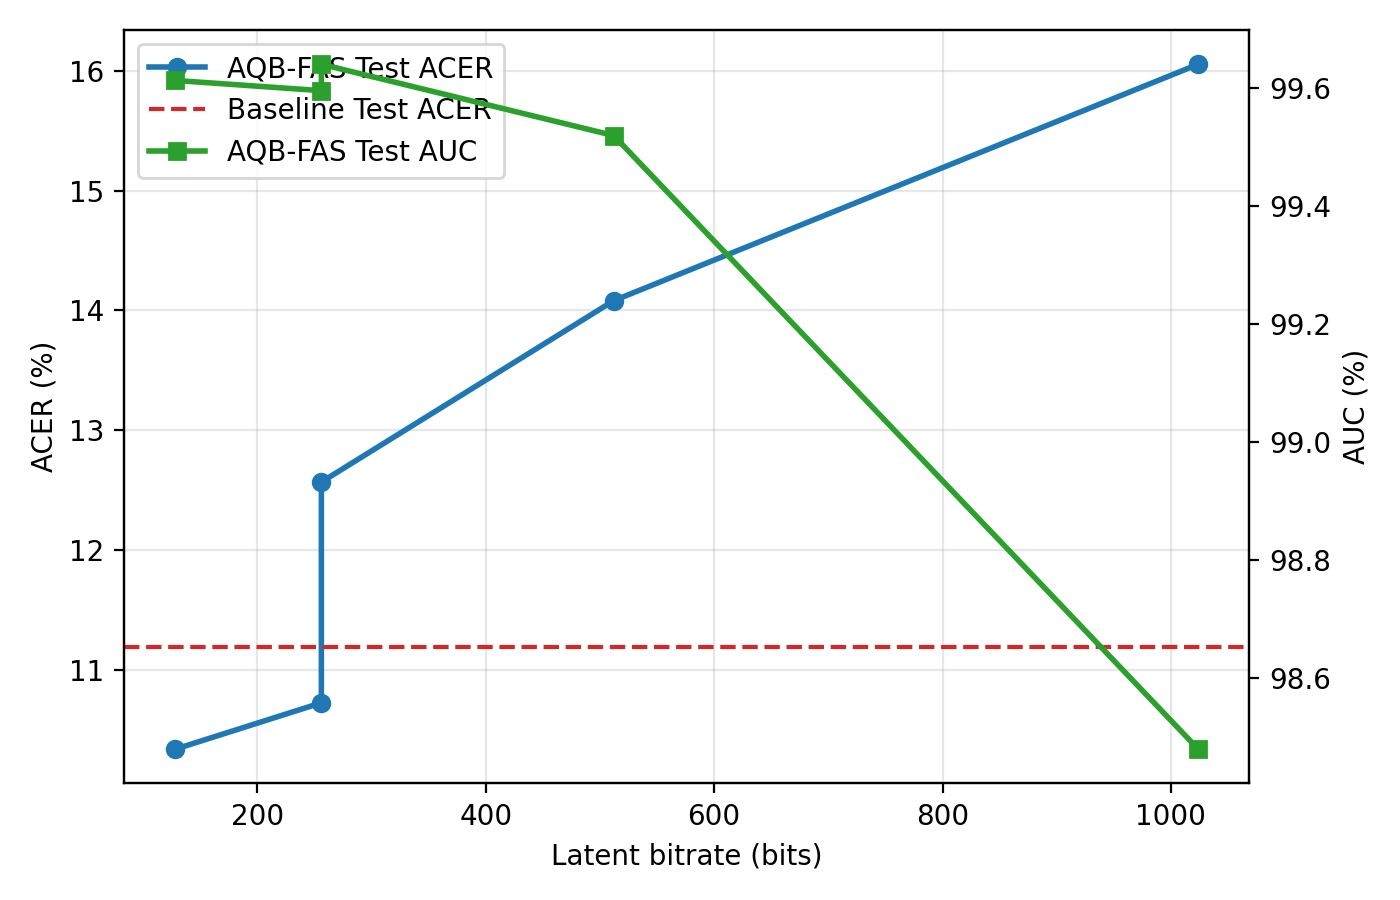

In [8]:
utility_path = FIGURES / 'utility_bitrate.png'
if utility_path.exists():
    display(Image(filename=str(utility_path)))
else:
    print('Missing', utility_path)

## 8. Gợi ý diễn giải cho paper

- Baseline hiện có Test ACER thấp hơn AQB-FAS z64 b8, nên AQB bản này chưa thắng baseline về ACER.
- AQB-FAS dùng latent 512 bits, vì vậy câu chuyện paper nên nhấn vào trade-off giữa bitrate và performance.
- Test AUC cao nhưng Test ACER còn cao cho thấy vấn đề calibration/threshold khi chuyển từ validation sang test.
- Cần chạy thêm các bitrate khác để có hình utility-vs-bitrate đủ thuyết phục.